# Emerging Technology Job Market Analysis

## Background
Emerging technology industries such as AI, Blockchain, Green Technology, and Quantum Computing are creating new career opportunities for university students. However, students may not know which technical skills are most relevant for each sector, or whether salary differences across industries are large enough to influence career choice.

## Research Question
How do skill requirements differ across AI, Blockchain, Green Technology, and Quantum Computing roles, and what do these differences suggest about salary and career preparation?

## Target User
The target users of this analysis are university students who are exploring career paths in emerging technology industries and want to understand which skills to prioritise.

## Analytical Focus
Preliminary analysis shows that average salaries across the four industries are relatively similar in this dataset. Therefore, this notebook focuses more on industry-specific skill demand, common job roles, and skill-level salary patterns than on ranking industries by average pay alone.

## Imports and Setup
This section imports the Python libraries and sets up the environment used for data analysis and visualisation.

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [3]:
df = pd.read_csv("future_jobs_dataset.csv")
df.head()


,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"Climate Data Analysis, Energy Modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"Rust, Solidity",Yes,Small,2025-03-30


## Data Loading
This section loads the future jobs dataset and checks its main columns, records, and overall structure.

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Shape: (10000, 9)

Columns:
['job_id', 'job_title', 'industry', 'location', 'salary_usd', 'skills_required', 'remote_option', 'company_size', 'posting_date']

Missing values:
job_id             0
job_title          0
industry           0
location           0
salary_usd         0
skills_required    0
remote_option      0
company_size       0
posting_date       0
dtype: int64


## Data Preparation
This section loads the dataset, keeps the variables needed for analysis, cleans salary values, and converts the skills field into a format suitable for frequency analysis.

In [5]:
cols = [
    "job_title",
    "industry",
    "salary_usd",
    "skills_required",
    "posting_date",
    "remote_option",
    "company_size"
]

df = df[cols].copy()
df[["job_title", "industry", "salary_usd", "skills_required"]].head(10)


,job_title,industry,salary_usd,skills_required
0,Quantum Researcher,Quantum Computing,175780,"Linear Algebra, Quantum Algorithms"
1,Renewable Energy Engineer,Green Tech,137481,"Climate Data Analysis, Energy Modeling"
2,Quantum Researcher,Quantum Computing,182081,"Linear Algebra, Qiskit"
3,Sustainability Analyst,Green Tech,113822,"Climate Data Analysis, Energy Modeling"
4,Smart Contract Engineer,Blockchain,92575,"Rust, Solidity"
5,Smart Contract Engineer,Blockchain,173379,"Solidity, Rust"
6,Renewable Energy Engineer,Green Tech,99659,"Climate Data Analysis, Energy Modeling"
7,Quantum Software Developer,Quantum Computing,210842,"Qiskit, Quantum Algorithms"
8,Sustainability Analyst,Green Tech,189475,"Climate Data Analysis, Energy Modeling"
9,Blockchain Developer,Blockchain,228992,"Ethereum, Solidity"


In [6]:
df["salary_usd"] = pd.to_numeric(df["salary_usd"], errors="coerce")
df["posting_date"] = pd.to_datetime(df["posting_date"], errors="coerce")

print(df[["salary_usd", "posting_date"]].dtypes)
print("\nMissing salary values:", df["salary_usd"].isna().sum())
print("Missing posting_date values:", df["posting_date"].isna().sum())

salary_usd               int64
posting_date    datetime64[ns]
dtype: object

Missing salary values: 0
Missing posting_date values: 0


In [7]:
def clean_skills(text):
    if pd.isna(text):
        return []
    
    # split by comma or semicolon
    parts = re.split(r"[;,]", str(text))
    
    # remove spaces and standardise to lowercase
    parts = [p.strip().lower() for p in parts if p.strip()]
    
    return parts

df["skill_list"] = df["skills_required"].apply(clean_skills)

df[["skills_required", "skill_list"]].head()

,skills_required,skill_list
0,"Linear Algebra, Quantum Algorithms","[linear algebra, quantum algorithms]"
1,"Climate Data Analysis, Energy Modeling","[climate data analysis, energy modeling]"
2,"Linear Algebra, Qiskit","[linear algebra, qiskit]"
3,"Climate Data Analysis, Energy Modeling","[climate data analysis, energy modeling]"
4,"Rust, Solidity","[rust, solidity]"


In [8]:
skills_df = df[["industry", "salary_usd", "job_title", "skill_list"]].explode("skill_list")
skills_df = skills_df.rename(columns={"skill_list": "skill"})
skills_df = skills_df.dropna(subset=["skill"])

skills_df.head()

,industry,salary_usd,job_title,skill
0,Quantum Computing,175780,Quantum Researcher,linear algebra
0,Quantum Computing,175780,Quantum Researcher,quantum algorithms
1,Green Tech,137481,Renewable Energy Engineer,climate data analysis
1,Green Tech,137481,Renewable Energy Engineer,energy modeling
2,Quantum Computing,182081,Quantum Researcher,linear algebra


In [9]:
skill_counts = skills_df["skill"].value_counts().reset_index()
skill_counts.columns = ["skill", "count"]

skill_counts.head(10)

,skill,count
0,climate data analysis,2490
1,energy modeling,2490
2,quantum algorithms,1690
3,tensorflow,1690
4,ethereum,1683
5,qiskit,1682
6,solidity,1669
7,linear algebra,1666
8,python,1657
9,rust,1646


## Analysis
This section examines which skills are most in demand in AI, Blockchain, Green Tech, and Quantum Computing, and how these skills relate to salary.

## Chart 1: Top 10 Most In-Demand Skills Overall
This chart identifies the most frequently requested skills across all emerging technology industries in the dataset.


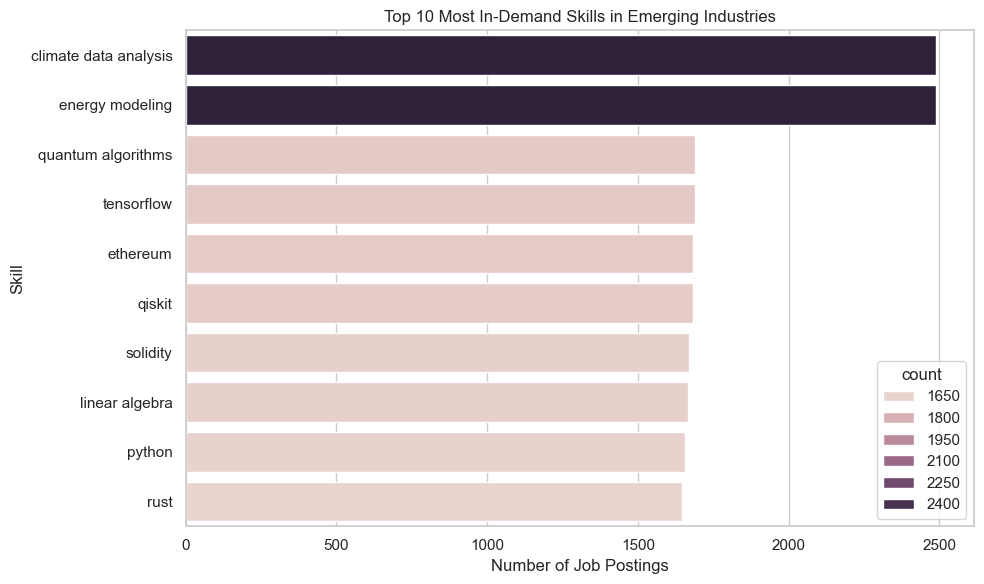

In [10]:
top10_skills = skill_counts.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_skills, x="count", y="skill", hue="count")
plt.title("Top 10 Most In-Demand Skills in Emerging Industries")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("chart1_top10_skills.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation
This chart shows which skills appear most frequently across all job postings. For students, these are likely to be the most broadly useful skills to prioritise.

## Chart 2: Skill Demand by Industry
Because industry-level average salaries are relatively similar in this dataset, it is more useful to compare how skill demand differs across industries.

In [11]:
top10_skill_names = top10_skills["skill"].tolist()

heatmap_data = (
    skills_df[skills_df["skill"].isin(top10_skill_names)]
    .groupby(["industry", "skill"])
    .size()
    .unstack(fill_value=0)
)

# reorder columns by overall popularity
heatmap_data = heatmap_data[top10_skill_names]

heatmap_data

skill,climate data analysis,energy modeling,quantum algorithms,tensorflow,ethereum,qiskit,solidity,linear algebra,python,rust
industry,,,,,,,,,,
AI,0,0,0,1690,0,0,0,0,1657,0
Blockchain,0,0,0,0,1683,0,1669,0,0,1646
Green Tech,2490,2490,0,0,0,0,0,0,0,0
Quantum Computing,0,0,1690,0,0,1682,0,1666,0,0


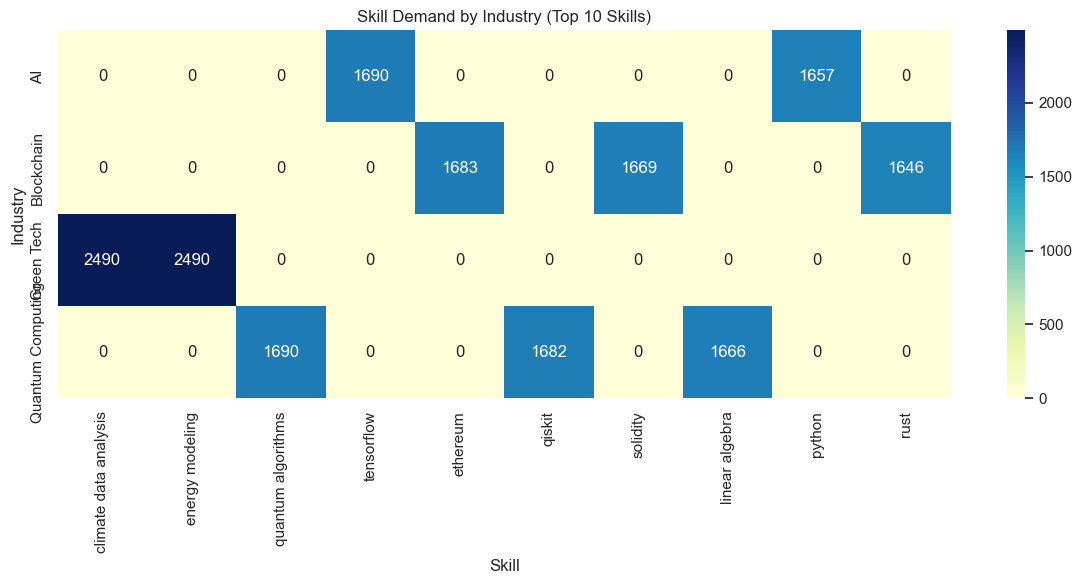

In [12]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Skill Demand by Industry (Top 10 Skills)")
plt.xlabel("Skill")
plt.ylabel("Industry")
plt.tight_layout()
plt.savefig("chart2_skill_demand_by_industry_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation
The heatmap shows a very clear separation of skill demand across industries. Green Tech roles are associated with climate data analysis and energy modeling, AI roles with TensorFlow, Blockchain roles with Ethereum and Solidity, and Quantum Computing roles with Qiskit, quantum algorithms, and linear algebra. There is very little overlap among the top skills across industries in this dataset. This suggests that students should choose skills based on their intended sector, because each emerging industry appears to require a distinct technical profile.

## Chart 3: Relative Average Salary by Industry (Lowest Industry = 0%)

This chart compares the average salary of each industry relative to the lowest-paying industry.


In [16]:
industry_salary = industry_salary_summary.reset_index()
min_salary_ind = industry_salary["mean"].min()
industry_salary["relative_salary_pct"] = (industry_salary["mean"] / min_salary_ind - 1) * 100
industry_salary

,industry,count,mean,median,min,max,relative_salary_pct
0,Quantum Computing,2519,151130.696308,151810.0,50013,249766,1.205918
1,AI,2492,150672.369181,151389.5,50060,249952,0.898996
2,Blockchain,2499,149383.765106,150395.0,50060,249990,0.036071
3,Green Tech,2490,149329.900000,147856.5,50072,249809,0.000000


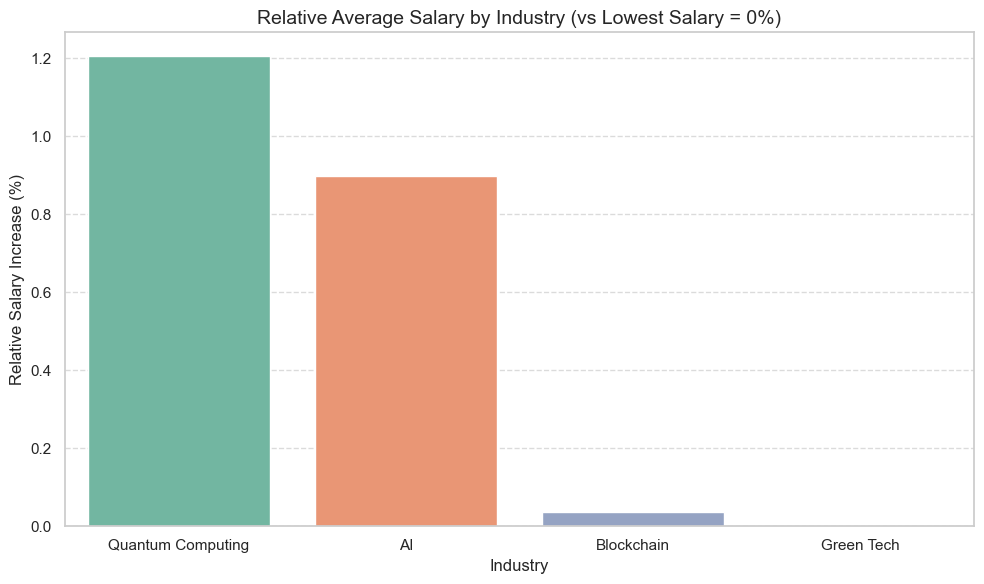

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=industry_salary, x="industry", y="relative_salary_pct", 
            hue="industry", palette="Set2")
plt.title("Relative Average Salary by Industry (vs Lowest Salary = 0%)", fontsize=14)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Relative Salary Increase (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("chart3_relative_salary_by_industry.png", dpi=300, bbox_inches="tight")
plt.show()

# Interpretation:
The chart shows that salary differences across industries are relatively small overall. Quantum Computing has the highest relative average salary, followed by AI, while Blockchain is only slightly above Green Tech, which serves as the baseline. This suggests that industry-level salary gaps in the dataset are limited, and industry alone may not strongly explain salary differences in emerging technology jobs.

## Chart 4: Relative Salary by Common Job Title (Lowest Job Title = 0%)

This chart compares the average salary of common job titles relative to the lowest-paying job title.


In [20]:
job_salary = df.groupby("job_title")["salary_usd"].agg(["mean"]).reset_index()
job_salary.rename(columns={"mean": "average_salary"}, inplace=True)
job_salary = job_salary.sort_values(by="average_salary", ascending=False)
min_salary = job_salary["average_salary"].min()
job_salary["relative_salary_pct"] = (job_salary["average_salary"] / min_salary - 1) * 100
job_salary

,job_title,average_salary,relative_salary_pct
5,Quantum Software Developer,151499.841941,2.580019
3,ML Researcher,151284.985222,2.434541
8,Sustainability Analyst,150991.592563,2.235885
2,Data Scientist,150990.363525,2.235053
7,Smart Contract Engineer,150779.203187,2.092077
4,Quantum Researcher,150750.544722,2.072673
0,AI Engineer,149794.911935,1.425617
1,Blockchain Developer,147975.987942,0.194030
6,Renewable Energy Engineer,147689.426177,0.000000


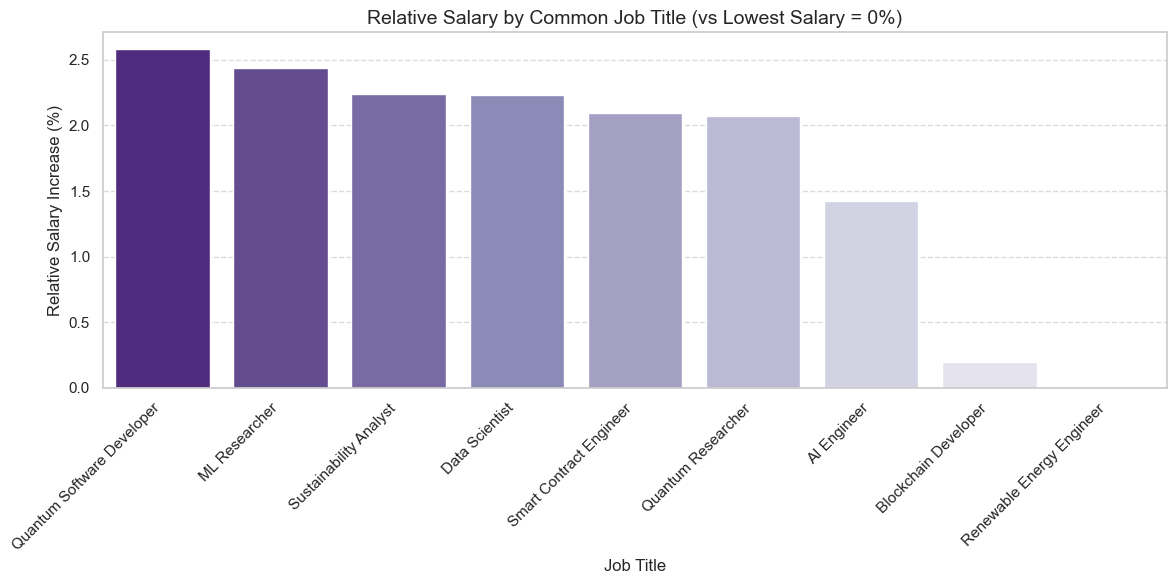

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=job_salary, x="job_title", y="relative_salary_pct", 
            hue="job_title", palette="Purples_r")
plt.title("Relative Salary by Common Job Title (vs Lowest Salary = 0%)", fontsize=14)
plt.xlabel("Job Title", fontsize=12)
plt.ylabel("Relative Salary Increase (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("chart4_relative_salary_by_job_title.png", dpi=300, bbox_inches="tight")
plt.show()

# Interpretation:
Compared with the industry-level comparison, salary differences across job titles are slightly clearer, although they are still modest overall. Quantum Software Developer has the highest relative salary, followed by ML Researcher and Sustainability Analyst, while Renewable Energy Engineer forms the baseline. This suggests that job title may explain salary variation better than industry, but the overall differences are still not very large in practical terms.

## Chart 5: Relative Salary for Selected High-Demand Skills (Lowest Skill = 0%)

This chart examines whether selected high-demand skills are associated with relatively higher salaries.


In [26]:
selected_skills = top10_skills["skill"].head(8).tolist()
selected_skills

['climate data analysis',
 'energy modeling',
 'quantum algorithms',
 'tensorflow',
 'ethereum',
 'qiskit',
 'solidity',
 'linear algebra']

In [27]:
skill_salary = (
    skills_df[skills_df["skill"].isin(selected_skills)]
    .groupby("skill")["salary_usd"]
    .agg(["mean", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

skill_salary.columns = ["skill", "average_salary", "job_count"]

skill_salary = skill_salary[skill_salary["job_count"] >= 5]
min_salary_skill = skill_salary["average_salary"].min()
skill_salary["relative_salary_pct"] = (skill_salary["average_salary"] / min_salary_skill - 1) * 100

skill_salary

,skill,average_salary,job_count,relative_salary_pct
4,qiskit,152261.042806,1682,2.153494
5,quantum algorithms,150687.381657,1690,1.097709
3,linear algebra,150439.195078,1666,0.931198
7,tensorflow,150162.359763,1690,0.745466
6,solidity,149482.702816,1669,0.289477
0,climate data analysis,149329.900000,2490,0.186960
1,energy modeling,149329.900000,2490,0.186960
2,ethereum,149051.233512,1683,0.000000


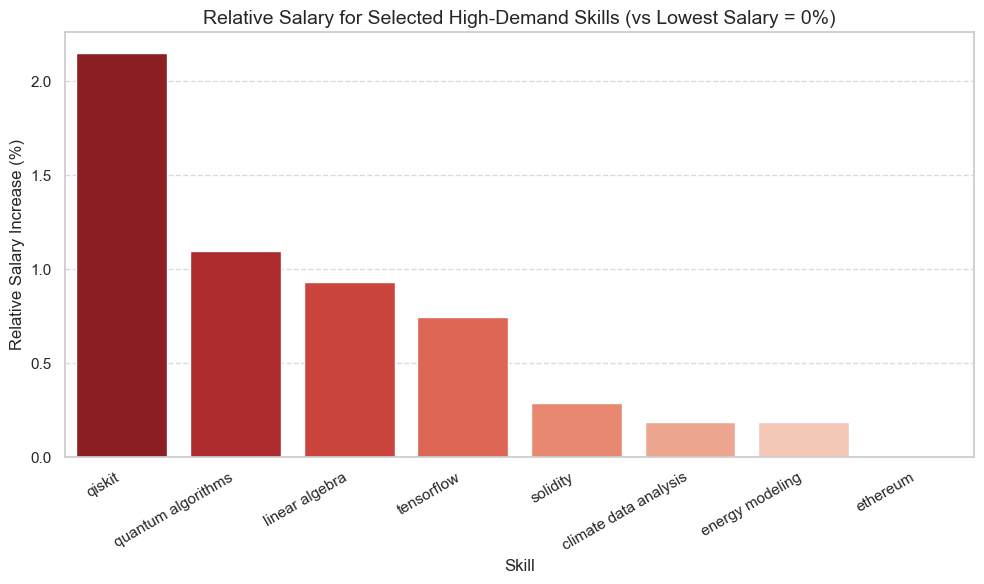

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=skill_salary,
    x="skill",
    y="relative_salary_pct",
    hue="skill",
    palette="Reds_r",
    dodge=False
)

plt.title("Relative Salary for Selected High-Demand Skills (vs Lowest Salary = 0%)", fontsize=14)
plt.xlabel("Skill", fontsize=12)
plt.ylabel("Relative Salary Increase (%)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("chart5_relative_salary_by_selected_skills.png", dpi=300, bbox_inches="tight")
plt.show()

# Interpretation:
Among the selected high-demand skills, qiskit shows the highest relative salary premium, followed by quantum algorithms and linear algebra. In contrast, climate data analysis and energy modeling remain close to the baseline. The chart suggests that some in-demand skills are associated with slightly higher salaries, but the differences are still small, meaning that high demand does not always lead to substantially higher pay.

## Key Results Summary
The following tables summarise the most important findings used in the conclusion.

In [30]:
print("Top 10 skills:")
display(top10_skills)

print("heatmap_data")
display(heatmap_data)

print("\nIndustry relative salary summary:")
display(industry_salary_summary)

print("\nRelative salary by common job title:")
display(job_salary)

print("\nRelative salary by selected high-demand skills:")
display(skill_salary)

Top 10 skills:


,skill,count
0,climate data analysis,2490
1,energy modeling,2490
2,quantum algorithms,1690
3,tensorflow,1690
4,ethereum,1683
5,qiskit,1682
6,solidity,1669
7,linear algebra,1666
8,python,1657
9,rust,1646


heatmap_data


skill,climate data analysis,energy modeling,quantum algorithms,tensorflow,ethereum,qiskit,solidity,linear algebra,python,rust
industry,,,,,,,,,,
AI,0,0,0,1690,0,0,0,0,1657,0
Blockchain,0,0,0,0,1683,0,1669,0,0,1646
Green Tech,2490,2490,0,0,0,0,0,0,0,0
Quantum Computing,0,0,1690,0,0,1682,0,1666,0,0



Industry relative salary summary:


,count,mean,median,min,max
industry,,,,,
Quantum Computing,2519,151130.696308,151810.0,50013,249766
AI,2492,150672.369181,151389.5,50060,249952
Blockchain,2499,149383.765106,150395.0,50060,249990
Green Tech,2490,149329.900000,147856.5,50072,249809



Relative salary by common job title:


,job_title,average_salary,relative_salary_pct
5,Quantum Software Developer,151499.841941,2.580019
3,ML Researcher,151284.985222,2.434541
8,Sustainability Analyst,150991.592563,2.235885
2,Data Scientist,150990.363525,2.235053
7,Smart Contract Engineer,150779.203187,2.092077
4,Quantum Researcher,150750.544722,2.072673
0,AI Engineer,149794.911935,1.425617
1,Blockchain Developer,147975.987942,0.194030
6,Renewable Energy Engineer,147689.426177,0.000000



Relative salary by selected high-demand skills:


,skill,average_salary,job_count,relative_salary_pct
4,qiskit,152261.042806,1682,2.153494
5,quantum algorithms,150687.381657,1690,1.097709
3,linear algebra,150439.195078,1666,0.931198
7,tensorflow,150162.359763,1690,0.745466
6,solidity,149482.702816,1669,0.289477
0,climate data analysis,149329.900000,2490,0.186960
1,energy modeling,149329.900000,2490,0.186960
2,ethereum,149051.233512,1683,0.000000


## Main Findings

This analysis shows that the most meaningful differences in the dataset are found in skill demand patterns rather than in industry-level salary differences. After converting salary comparisons into relative salary percentages, the results still show that salary gaps across industries are small overall. Quantum Computing has the highest relative average salary, followed by AI, while Blockchain is only slightly above Green Tech. This suggests that industry alone is not the strongest explanation for salary variation in this dataset.

In contrast, skill demand appears to be highly industry-specific. Green Tech roles are strongly associated with climate data analysis and energy modeling, AI roles with TensorFlow, Blockchain roles with Ethereum and Solidity, and Quantum Computing roles with qiskit, quantum algorithms, and linear algebra. This indicates that emerging technology sectors require distinct technical skill sets rather than one common group of skills.

The analysis also suggests that salary differences become slightly clearer when examined at the job-title and skill level. Among common job titles, Quantum Software Developer and ML Researcher have the highest relative salaries, while among selected high-demand skills, qiskit shows the highest relative salary premium. However, these differences are still modest overall, so they should be interpreted cautiously rather than as large pay gaps.

## Practical Value

For university students planning careers in emerging technology industries, these findings suggest that it may be more useful to focus on learning sector-relevant skills than to choose a field based only on average salary. Since salary levels are relatively similar across the four industries, students may benefit more from identifying which industry matches their interests and then building the technical skills most demanded in that sector.

## Limitations

This analysis is based on one dataset and may not fully represent the wider labour market. In addition, many skills in the dataset appear to be strongly tied to specific industries, which may reduce overlap between sectors. Salary differences are also relatively narrow, and the relative salary percentages in this project are calculated against the lowest group within each comparison, so the results are best understood as comparative rather than absolute pay differences. Therefore, stronger conclusions about salary advantages should be made with caution.

## Conclusion

Overall, this project suggests that emerging technology career choices may be better guided by skill demand than by small differences in average salary across industries. The findings are most useful for students who want to compare career paths in AI, Blockchain, Green Tech, and Quantum Computing, and decide which skills to prioritise for future employability.

